In [28]:
'''
Script for preprocessing galaxy images.

Following the AION-1 Paper from Parker at al 2025.

'''
from __future__ import annotations
import torch


# Keeps track of the band indices for HSC and DES bands
BAND_TO_INDEX = {
    "HSC-G": 0,
    "HSC-R": 1,
    "HSC-I": 2,
    "HSC-Z": 3,
    "HSC-Y": 4,
    "DES-G": 5,
    "DES-R": 6,
    "DES-I": 7,
    "DES-Z": 8,
}
# Maximum band center values for HSC and DES bands
BAND_CENTER_MAX = {
    "HSC-G": 80,
    "HSC-R": 110,
    "HSC-I": 200,
    "HSC-Z": 330,
    "HSC-Y": 500,
    "DES-G": 6,
    "DES-R": 15,
    "DES-I": 20,
    "DES-Z": 25,
}

class CenterCrop:
    """Formatter that crops the images to have a fixed number of bands."""

    def __init__(self, crop_size: int = 96):
        self.crop_size = crop_size

    def __call__(self, image):
        _, _, height, width = image.shape
        start_x = (width - self.crop_size) // 2
        start_y = (height - self.crop_size) // 2
        return image[
            :, :, start_y : start_y + self.crop_size, start_x : start_x + self.crop_size
        ]


class Clamp:
    """Formatter that clamps the images to a given range."""

    def __init__(self):
        self.clamp_dict = BAND_CENTER_MAX

    def __call__(self, image, bands):
        for i, band in enumerate(bands):
            image[:, i, :, :] = torch.clip(
                image[:, i, :, :], -self.clamp_dict[band], self.clamp_dict[band]
            )
        return image


class RescaleToLegacySurvey:
    """Formatter that rescales the images to have a fixed number of bands."""

    def __init__(self):
        pass

    def convert_zeropoint(self, zp: float) -> float:
        return 10.0 ** ((zp - 22.5) / 2.5)

    def reverse_zeropoint(self, scale: float) -> float:
        return 22.5 - 2.5 * torch.log10(scale)

    def forward(self, image, survey):
        zpscale = self.convert_zeropoint(27.0) if survey == "HSC" else 1.0
        image /= zpscale
        return image

    def backward(self, image, survey):
        zpscale = self._reverse_zeropoint(27.0) if survey == "HSC" else 1.0
        image *= zpscale
        return image


In [29]:
import glob
import os
import random
from typing import Iterable, List, Optional, Sequence, Tuple

import numpy as np
import torch
from datasets import load_dataset
dataset_path = '/mnt/scratch/legacysurvey_hsc_crossmatched/data'
catalog_name = "legacysurvey_hsc_crossmatched"
files_to_use = 1
pattern = os.path.join(dataset_path, "*.parquet")
all_files = sorted(glob.glob(pattern))
dataset=load_dataset(
        "parquet",
        data_files=all_files,
        split="train"
    )
idx = 10
example_record = dataset[idx]

# print(example_record.keys() )
hsc_image = np.array(example_record['hsc_image']['flux'])
legacysurvey_image = np.array(example_record['legacysurvey_image']['flux'])

print(hsc_image.shape)
print(legacysurvey_image.shape)

hsc_image_tensor = torch.from_numpy(hsc_image).float()
legacysurvey_image_tensor = torch.from_numpy(legacysurvey_image).float()
print(hsc_image_tensor.shape)
print(legacysurvey_image_tensor.shape)


#Lets test the classes

cropper = CenterCrop(crop_size=96)
clamper = Clamp()
rescaler = RescaleToLegacySurvey()


(5, 160, 160)
(4, 160, 160)
torch.Size([5, 160, 160])
torch.Size([4, 160, 160])


/tmp/ipykernel_1263136/1490504464.py:11: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  im1_rescaled_arcsinh = np.arcsinh(im1_rescaled)
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.30593765..4.6664968].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.30593765..4.6664968].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.30593765..4.6664968].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.004848785..0.07395899].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.004848766..0.07389174].


Range of original image:  tensor(-0.3059) tensor(4.6665)
Range of cropped image:  tensor(-0.3059) tensor(4.6665)
Range of clamped image:  tensor(-0.3059) tensor(4.6665)
Range of rescaled image:  tensor(-0.0048) tensor(0.0740)
Range of rescaled normalized image:  tensor(0.) tensor(1.)
Range of arcsinh image:  tensor(-0.0048) tensor(0.0739)


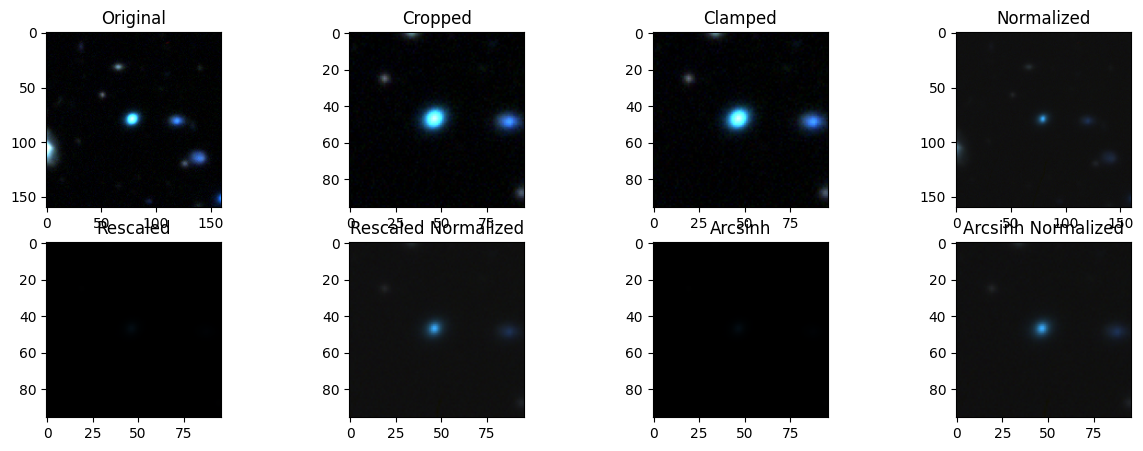

In [34]:
import matplotlib.pyplot as plt
im1=hsc_image_tensor[1:4,:,:]
im1_cropped=cropper(im1.unsqueeze(0)).squeeze(0)
im1_clamped=clamper(im1_cropped.unsqueeze(0), ['HSC-R', 'HSC-I', 'HSC-Z']).squeeze(0)
im1_rescaled = rescaler.forward(im1_clamped.clone().unsqueeze(0), 'HSC').squeeze(0)

#Normalize the rescaled one to 0-1
im1_rescaled_normalized = (im1_rescaled - im1_rescaled.min()) / (im1_rescaled.max() - im1_rescaled.min())

#do arcsinh of rescaled image
im1_rescaled_arcsinh = np.arcsinh(im1_rescaled)
im1_rescaled_arcsinh_normalized = (im1_rescaled_arcsinh - im1_rescaled_arcsinh.min()) / (im1_rescaled_arcsinh.max() - im1_rescaled_arcsinh.min())

#original normalized
im1_normalized = (im1 - im1.min()) / (im1.max() - im1.min())

print('Range of original image: ', im1.min(), im1.max())
print('Range of cropped image: ', im1_cropped.min(), im1_cropped.max())
print('Range of clamped image: ', im1_clamped.min(), im1_clamped.max())
print('Range of rescaled image: ', im1_rescaled.min(), im1_rescaled.max())
print('Range of rescaled normalized image: ', im1_rescaled_normalized.min(), im1_rescaled_normalized.max())
print('Range of arcsinh image: ', im1_rescaled_arcsinh.min(), im1_rescaled_arcsinh.max())

fig, axs = plt.subplots(2, 4, figsize=(15, 5))
axs[0,0].imshow(im1.numpy().transpose(1,2,0))
axs[0,0].set_title('Original')
axs[0,1].imshow(im1_cropped.numpy().transpose(1,2,0))
axs[0,1].set_title('Cropped')
axs[0,2].imshow(im1_clamped.numpy().transpose(1,2,0))
axs[0,2].set_title('Clamped')
axs[0,3].imshow(im1_normalized.numpy().transpose(1,2,0))
axs[0,3].set_title('Normalized')
axs[1,0].imshow(im1_rescaled.numpy().transpose(1,2,0))
axs[1,0].set_title('Rescaled')
axs[1,1].imshow(im1_rescaled_normalized.numpy().transpose(1,2,0))
axs[1,1].set_title('Rescaled Normalized')
axs[1,2].imshow(im1_rescaled_arcsinh.numpy().transpose(1,2,0))
axs[1,2].set_title('Arcsinh')
axs[1,3].imshow(im1_rescaled_arcsinh_normalized.numpy().transpose(1,2,0))
axs[1,3].set_title('Arcsinh Normalized')
plt.show()


FULL PREPROCESSING PIPELINE

1. Original image shape: torch.Size([1, 5, 160, 160])
   Range: [-0.4125, 8.0761]

2. After center_crop (96x96): torch.Size([1, 5, 96, 96])
   Range: [-0.4125, 8.0761]

3. After clamp: torch.Size([1, 5, 96, 96])
   Range: [-0.4125, 8.0761]
   (Clamped to band-specific ranges)

4. After rescale.forward (survey=HSC): torch.Size([1, 5, 96, 96])
   Range: [-0.0065, 0.1280]
   Zeropoint scale factor: 63.095734

5. After range_compress: torch.Size([1, 5, 96, 96])
   Range: [-0.0614, 0.3244]
   range_compression_factor: 0.01
   mult_factor: 10.0
   Formula: arcsinh(x / 0.01) * 0.01 * 10.0

SUMMARY OF TRANSFORMATIONS
Original range:     [-0.4125, 8.0761]
Cropped range:     [-0.4125, 8.0761]
Clamped range:     [-0.4125, 8.0761]
Rescaled range:    [-0.0065, 0.1280]
Range compressed:  [-0.0614, 0.3244]


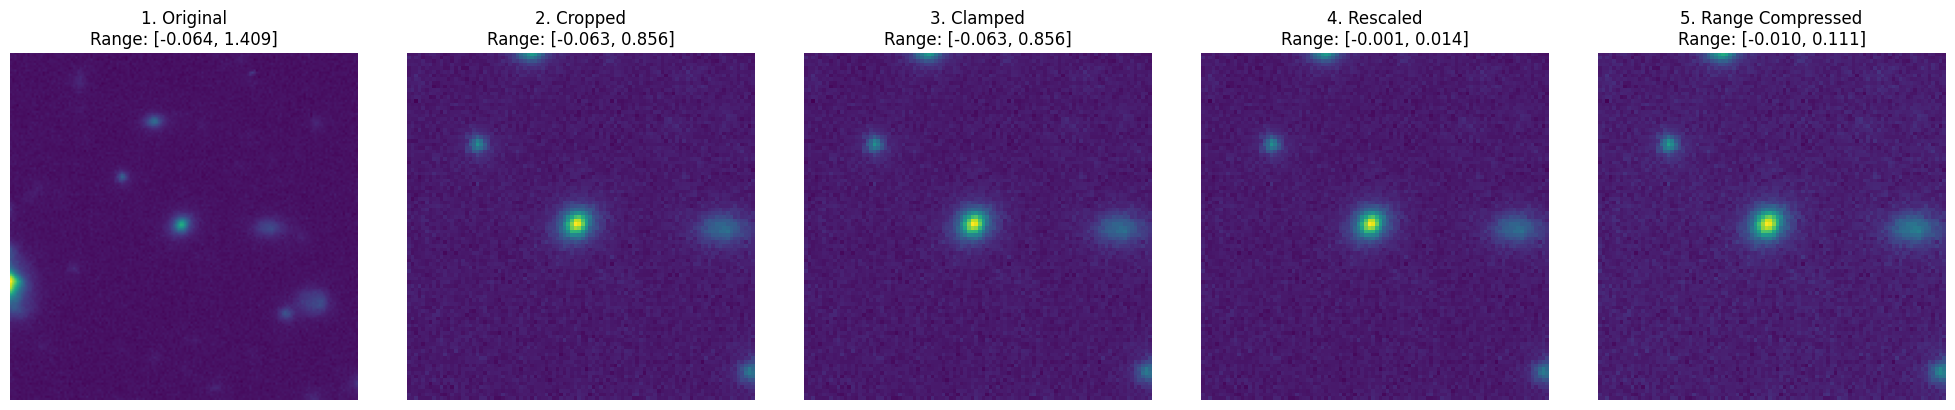

In [35]:
# Full preprocessing pipeline as done in AutoencoderImageCodec._encode()
# This demonstrates all the steps including range compression

# Parameters from the codec
range_compression_factor = 0.01
mult_factor = 10.0

# Start with the full HSC image (all 5 bands)
bands_in = ['HSC-G', 'HSC-R', 'HSC-I', 'HSC-Z', 'HSC-Y']
im_full = hsc_image_tensor.unsqueeze(0)  # Add batch dimension: [1, 5, 160, 160]

print("=" * 60)
print("FULL PREPROCESSING PIPELINE")
print("=" * 60)
print(f"\n1. Original image shape: {im_full.shape}")
print(f"   Range: [{im_full.min():.4f}, {im_full.max():.4f}]")

# Step 1: Center crop
im_cropped = cropper(im_full)
print(f"\n2. After center_crop (96x96): {im_cropped.shape}")
print(f"   Range: [{im_cropped.min():.4f}, {im_cropped.max():.4f}]")

# Step 2: Clamp
im_clamped = clamper(im_cropped.clone(), bands_in)
print(f"\n3. After clamp: {im_clamped.shape}")
print(f"   Range: [{im_clamped.min():.4f}, {im_clamped.max():.4f}]")
print(f"   (Clamped to band-specific ranges)")

# Step 3: Rescale to Legacy Survey
survey = bands_in[0].split("-")[0]  # Extract "HSC" from "HSC-G"
im_rescaled = rescaler.forward(im_clamped.clone(), survey)
print(f"\n4. After rescale.forward (survey={survey}): {im_rescaled.shape}")
print(f"   Range: [{im_rescaled.min():.4f}, {im_rescaled.max():.4f}]")
zpscale = rescaler.convert_zeropoint(27.0) if survey == "HSC" else 1.0
print(f"   Zeropoint scale factor: {zpscale:.6f}")

# Step 4: Range compression
# This is the key step: arcsinh(x / range_compression_factor) * range_compression_factor * mult_factor
im_range_compressed = (
    torch.arcsinh(im_rescaled / range_compression_factor)
    * range_compression_factor
)
im_range_compressed = im_range_compressed * mult_factor
print(f"\n5. After range_compress: {im_range_compressed.shape}")
print(f"   Range: [{im_range_compressed.min():.4f}, {im_range_compressed.max():.4f}]")
print(f"   range_compression_factor: {range_compression_factor}")
print(f"   mult_factor: {mult_factor}")
print(f"   Formula: arcsinh(x / {range_compression_factor}) * {range_compression_factor} * {mult_factor}")

# Summary
print("\n" + "=" * 60)
print("SUMMARY OF TRANSFORMATIONS")
print("=" * 60)
print(f"Original range:     [{im_full.min():.4f}, {im_full.max():.4f}]")
print(f"Cropped range:     [{im_cropped.min():.4f}, {im_cropped.max():.4f}]")
print(f"Clamped range:     [{im_clamped.min():.4f}, {im_clamped.max():.4f}]")
print(f"Rescaled range:    [{im_rescaled.min():.4f}, {im_rescaled.max():.4f}]")
print(f"Range compressed:  [{im_range_compressed.min():.4f}, {im_range_compressed.max():.4f}]")
print("=" * 60)

# Visualize a single band (HSC-R, index 1) through the pipeline
band_idx = 1  # HSC-R
fig, axs = plt.subplots(1, 5, figsize=(20, 4))

# Normalize each for visualization
im_orig_vis = im_full[0, band_idx].numpy()
im_orig_vis = (im_orig_vis - im_orig_vis.min()) / (im_orig_vis.max() - im_orig_vis.min() + 1e-8)

im_crop_vis = im_cropped[0, band_idx].numpy()
im_crop_vis = (im_crop_vis - im_crop_vis.min()) / (im_crop_vis.max() - im_crop_vis.min() + 1e-8)

im_clamp_vis = im_clamped[0, band_idx].numpy()
im_clamp_vis = (im_clamp_vis - im_clamp_vis.min()) / (im_clamp_vis.max() - im_clamp_vis.min() + 1e-8)

im_rescale_vis = im_rescaled[0, band_idx].numpy()
im_rescale_vis = (im_rescale_vis - im_rescale_vis.min()) / (im_rescale_vis.max() - im_rescale_vis.min() + 1e-8)

im_rc_vis = im_range_compressed[0, band_idx].numpy()
im_rc_vis = (im_rc_vis - im_rc_vis.min()) / (im_rc_vis.max() - im_rc_vis.min() + 1e-8)

axs[0].imshow(im_orig_vis, cmap='viridis')
axs[0].set_title(f'1. Original\nRange: [{im_full[0, band_idx].min():.3f}, {im_full[0, band_idx].max():.3f}]')
axs[0].axis('off')

axs[1].imshow(im_crop_vis, cmap='viridis')
axs[1].set_title(f'2. Cropped\nRange: [{im_cropped[0, band_idx].min():.3f}, {im_cropped[0, band_idx].max():.3f}]')
axs[1].axis('off')

axs[2].imshow(im_clamp_vis, cmap='viridis')
axs[2].set_title(f'3. Clamped\nRange: [{im_clamped[0, band_idx].min():.3f}, {im_clamped[0, band_idx].max():.3f}]')
axs[2].axis('off')

axs[3].imshow(im_rescale_vis, cmap='viridis')
axs[3].set_title(f'4. Rescaled\nRange: [{im_rescaled[0, band_idx].min():.3f}, {im_rescaled[0, band_idx].max():.3f}]')
axs[3].axis('off')

axs[4].imshow(im_rc_vis, cmap='viridis')
axs[4].set_title(f'5. Range Compressed\nRange: [{im_range_compressed[0, band_idx].min():.3f}, {im_range_compressed[0, band_idx].max():.3f}]')
axs[4].axis('off')

plt.tight_layout()
plt.show()
